# Framework communes accuracy

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [54]:
import matplotlib.pyplot as plt

from src.datasources import codab, anadia, abn
from src.constants import *
from src.utils import shift_to_floodseason_corrected

In [21]:
adm3 = codab.load_codab(admin_level=3, aoi_only=True)
adm3_aoi = adm3[adm3["ADM3_PCODE"].isin(ADM3_AOI_PCODES)]

In [26]:
impact = anadia.load_processed_anadia()
impact = impact.rename(columns={"Maisons détruites": "destroyed"})
impact_aoi = impact[impact["ADM3_PCODE"].isin(ADM3_AOI_PCODES)].copy()

In [102]:
impact_aoi["year"].max()

2020

In [45]:
level = abn.load_abn_niamey().reset_index()
level = level.rename(columns={"Date": "date", "Water Level (cm)": "level"})
level = shift_to_floodseason_corrected(level)
level = level[level["seasonyear"].isin(range(2005, 2022))]
peaks = level.groupby("seasonyear")["level"].max().reset_index()

In [46]:
peaks

,seasonyear,level
0,2005,501.000
1,2006,512.000
2,2007,525.000
3,2008,528.667
4,2009,528.000
5,2010,565.000
6,2011,528.000
7,2012,616.667
8,2013,611.750
9,2014,515.000


In [27]:
impact_aoi = shift_to_floodseason_corrected(impact_aoi)

In [31]:
impact_aoi

,idEvent,Régions,Départments,Communes,Type Commune,Localités,Code Renaloc,Type localité,Source localité,Ville,...,Postes radio détruits,Centres de santé détruits,date,match_adm3,rowcacode3,ADM3_PCODE,year,dayofyear,dayofseason,seasonyear
64,4321.0,DOSSO,GAYA,GAYA,URBAINE,KOYZE KOUNDA,30603056,QUARTIER,RENALOC,GAYA,...,0.0,0.0,2018-01-01,gaya,NER003006003,NE003006003,2018,1,215,2017
65,3150.0,DOSSO,GAYA,GAYA,URBAINE,ZONGO,30603063,QUARTIER,RENALOC,GAYA,...,0.0,0.0,2017-09-13,gaya,NER003006003,NE003006003,2017,256,105,2017
66,1747.0,DOSSO,GAYA,GAYA,URBAINE,NON DISPONIBLE,NON DISPONIBLE,NON DISPONIBLE,NON DISPONIBLE,NON DISPONIBLE,...,0.0,0.0,1999-01-01,gaya,NER003006003,NE003006003,1999,1,215,1998
67,4396.0,DOSSO,GAYA,GAYA,URBAINE,KOIRA TEGUI,30603025,VILLAGE,RENALOC,GAYA,...,0.0,0.0,2018-01-01,gaya,NER003006003,NE003006003,2018,1,215,2017
68,2117.0,DOSSO,GAYA,GAYA,URBAINE,NON DISPONIBLE,NON DISPONIBLE,NON DISPONIBLE,NON DISPONIBLE,NON DISPONIBLE,...,0.0,0.0,2012-01-01,gaya,NER003006003,NE003006003,2012,1,215,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,3512.0,DOSSO,GAYA,TOUNOUGA,RURALE,TOUNGA ZANOUA,30605072,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,2018-01-01,tounouga,NER003006005,NE003006005,2018,1,215,2017
1369,3189.0,DOSSO,GAYA,TOUNOUGA,RURALE,TOUNGAN MAMANE,30605077,HAMEAU,RENALOC,NON DISPONIBLE,...,0.0,0.0,2017-09-13,tounouga,NER003006005,NE003006005,2017,256,105,2017
1370,2368.0,DOSSO,GAYA,TOUNOUGA,RURALE,GONDAROU,30605024,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,2010-01-01,tounouga,NER003006005,NE003006005,2010,1,215,2009
1371,3508.0,DOSSO,GAYA,TOUNOUGA,RURALE,GATTAWANI KAINA,30605021,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,2018-01-01,tounouga,NER003006005,NE003006005,2018,1,215,2017


In [83]:
# impact_year = (
#     impact_aoi.groupby(["seasonyear"])["destroyed"].sum().reset_index()
# )
impact_year = impact_aoi.groupby(["year"])["destroyed"].sum().reset_index()

In [122]:
impact_year.sort_values("year")

,year,destroyed
0,1999,0.0
1,2003,241.0
2,2007,343.0
3,2010,278.0
4,2011,17.0
5,2012,4463.0
6,2013,2864.0
7,2015,1177.0
8,2016,87.0
9,2017,2257.0


In [142]:
compare = impact_year.merge(
    peaks.rename(columns={"seasonyear": "year"})
).fillna(0)
# compare = (
#     impact_year.rename(columns={"seasonyear": "year"})
#     .merge(peaks.rename(columns={"seasonyear": "year"}), how="right")
#     .fillna(0)
# )

In [143]:
q = impact_year["destroyed"].quantile(q=2 / 3 + 0.01)

In [144]:
q

1306.5999999999972

In [145]:
impact_year[impact_year["destroyed"] > q]

,year,destroyed
5,2012,4463.0
6,2013,2864.0
9,2017,2257.0
10,2018,5838.0


In [146]:
13 / 4

3.25

In [151]:
compare = compare[(compare["year"] < 2021) & (compare["year"] >= 2010)]

In [152]:
compare

,year,destroyed,level
1,2010,278.0,565.000
2,2011,17.0,528.000
3,2012,4463.0,616.667
4,2013,2864.0,611.750
5,2015,1177.0,579.667
6,2016,87.0,602.667
7,2017,2257.0,595.667
8,2018,5838.0,592.000
9,2019,263.0,636.000
10,2020,6.0,699.333


(518.35, 720.0)

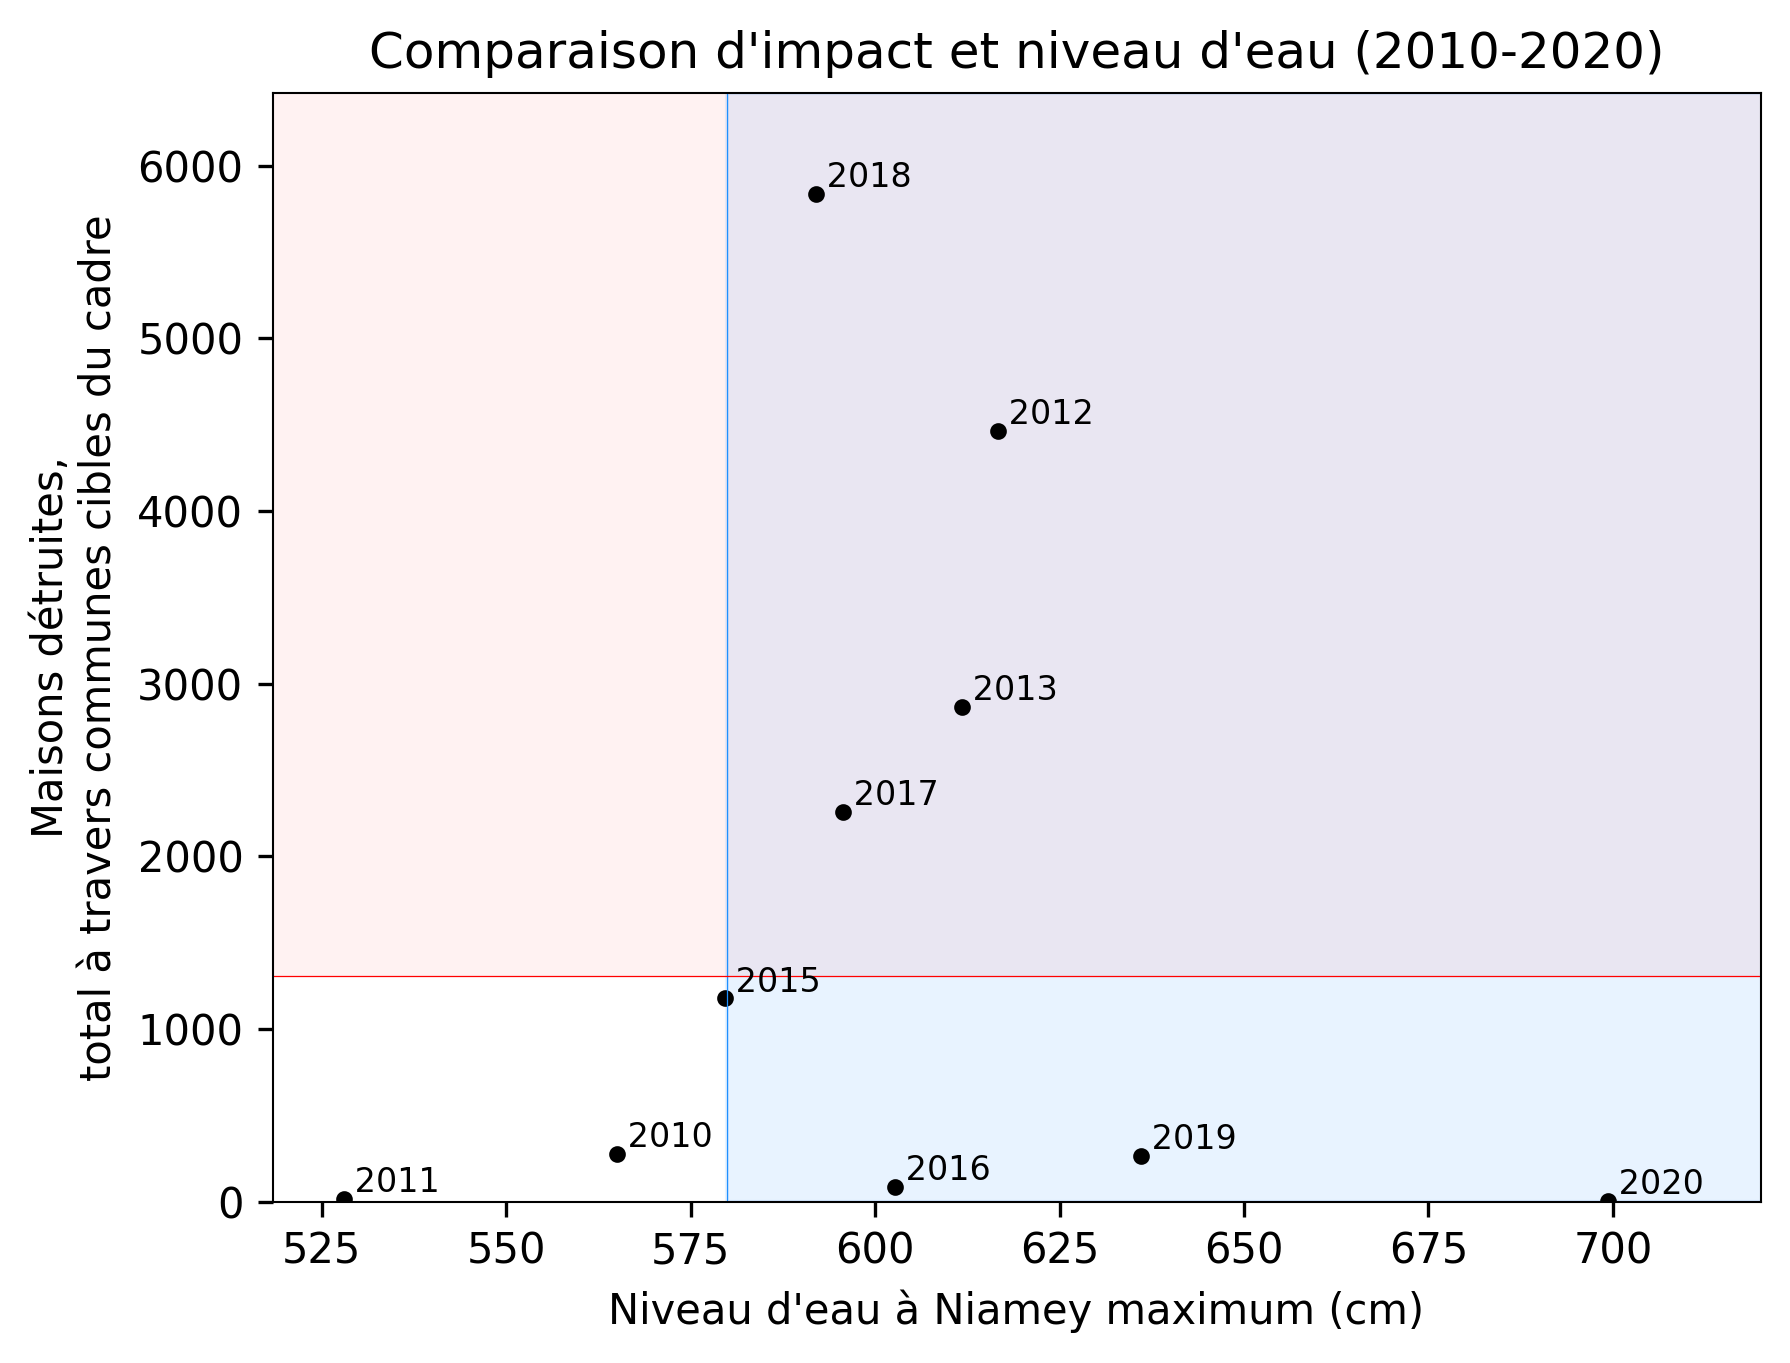

In [155]:
fig, ax = plt.subplots(dpi=300)

compare.plot(
    x="level",
    y="destroyed",
    ax=ax,
    marker=".",
    linestyle="",
    color="k",
    legend=False,
)
for idx, row in compare.iterrows():
    ax.annotate(
        f' {int(row["year"])}',
        (row["level"], row["destroyed"]),
        ha="left",
        va="bottom",
        fontsize=8,
        color="black",
    )

level_t = 580
ax.axvline(x=level_t, color="dodgerblue", linestyle="-", linewidth=0.3)
ax.axvspan(
    level_t,
    720 + 1,
    ymin=0,
    ymax=1,
    color="dodgerblue",
    alpha=0.1,
)

q = impact_year["destroyed"].quantile(q=2 / 3 + 0.01)
ax.axhline(y=q, color="red", linestyle="-", linewidth=0.3)
ax.axhspan(
    q,
    compare["destroyed"].max() * 1.2,
    color="red",
    alpha=0.05,
    linestyle="None",
)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.set_xlabel("Niveau d'eau à Niamey maximum (cm)")
ax.set_ylabel("Maisons détruites,\ntotal à travers communes cibles du cadre")
ax.set_title("Comparaison d'impact et niveau d'eau (2010-2020)")
ax.set_ylim(bottom=0, top=compare["destroyed"].max() * 1.1)
ax.set_xlim(right=720)

In [154]:
compare

,year,destroyed,level
1,2010,278.0,565.000
2,2011,17.0,528.000
3,2012,4463.0,616.667
4,2013,2864.0,611.750
5,2015,1177.0,579.667
6,2016,87.0,602.667
7,2017,2257.0,595.667
8,2018,5838.0,592.000
9,2019,263.0,636.000
10,2020,6.0,699.333


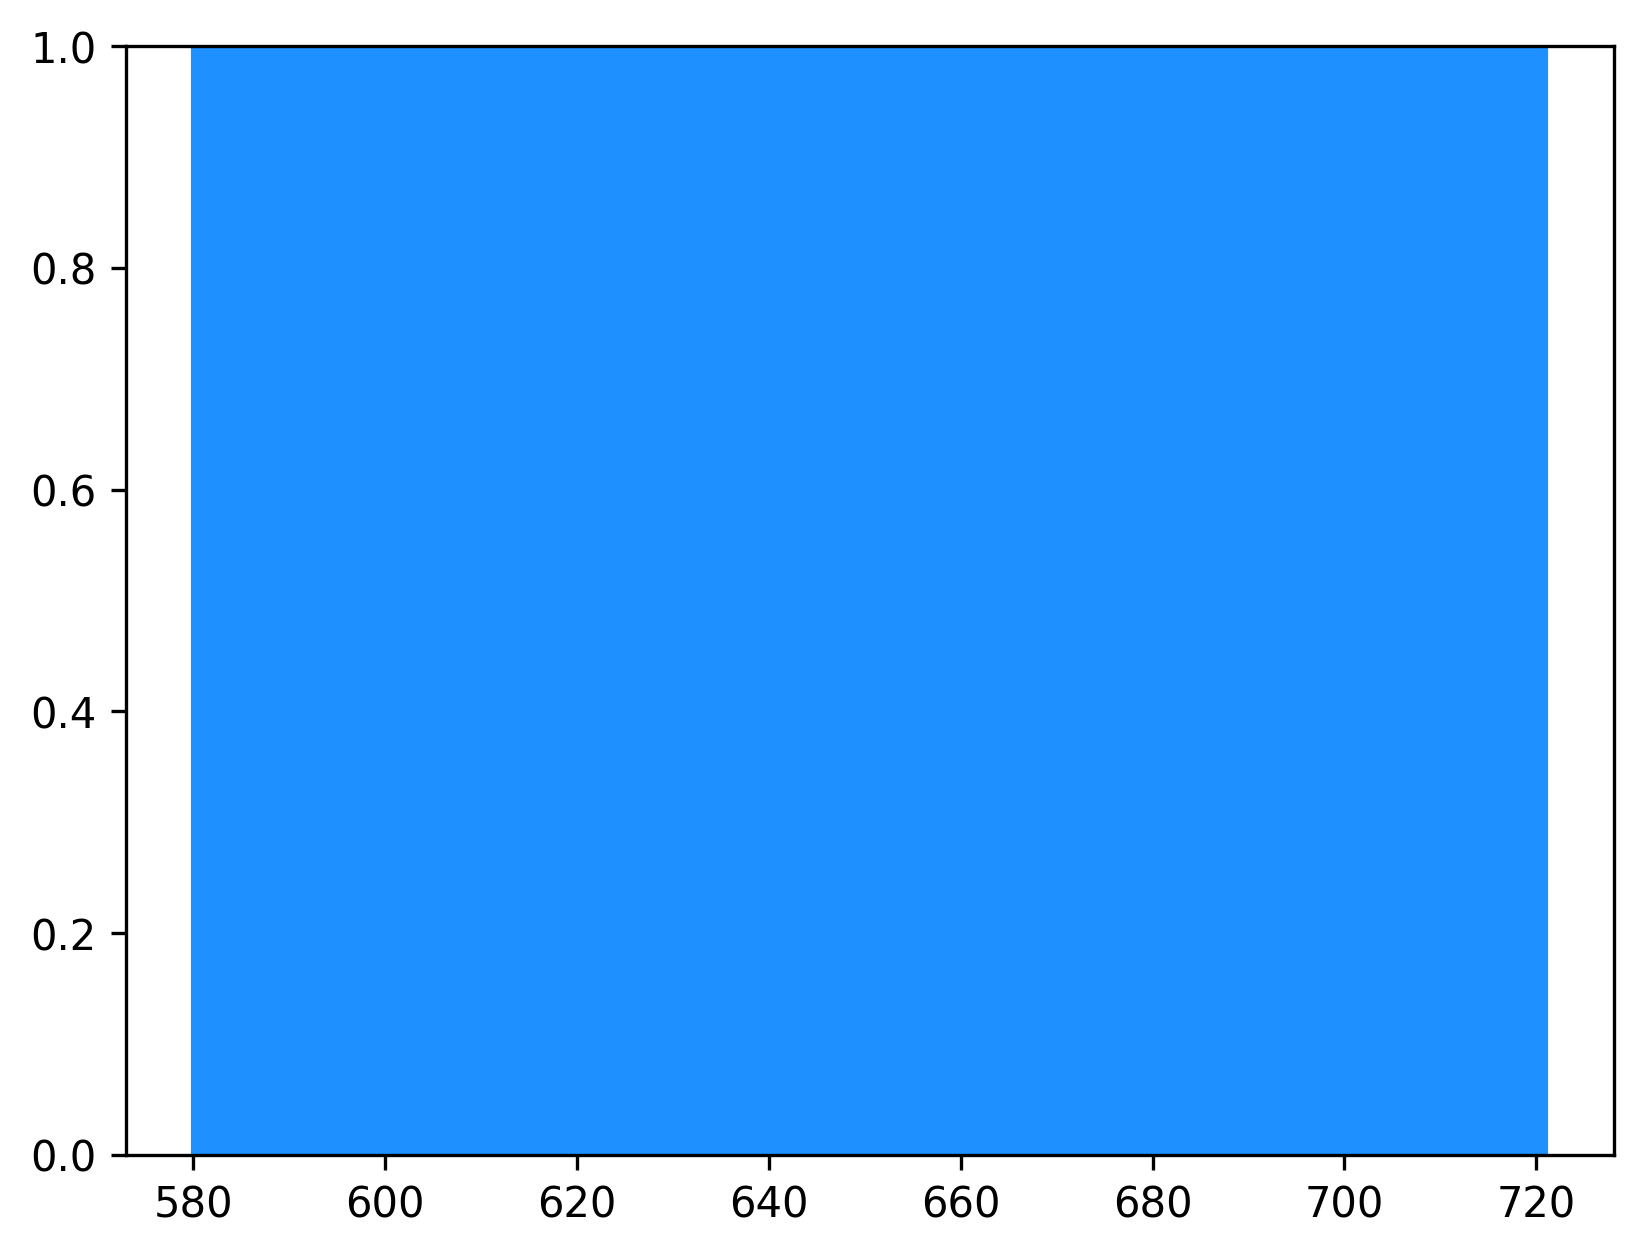

In [114]:
fig, ax = plt.subplots(dpi=300)

ax.axvspan(
    level_t,
    720 + 1,
    ymin=0,
    ymax=1,
    color="dodgerblue",
    alpha=1,
)

In [109]:
(2020 - 2005 + 1) / 5

3.2

In [110]:
peaks

,seasonyear,level
0,2005,501.000
1,2006,512.000
2,2007,525.000
3,2008,528.667
4,2009,528.000
5,2010,565.000
6,2011,528.000
7,2012,616.667
8,2013,611.750
9,2014,515.000
